📉 Best Val Loss: 0.2516 at Epoch 9
✅ Best Top-1 Accuracy: 0.9376 at Epoch 138
📊 Best F1 Score: 0.9374 at Epoch 44
📈 Best AUROC: 0.9935 at Epoch 44


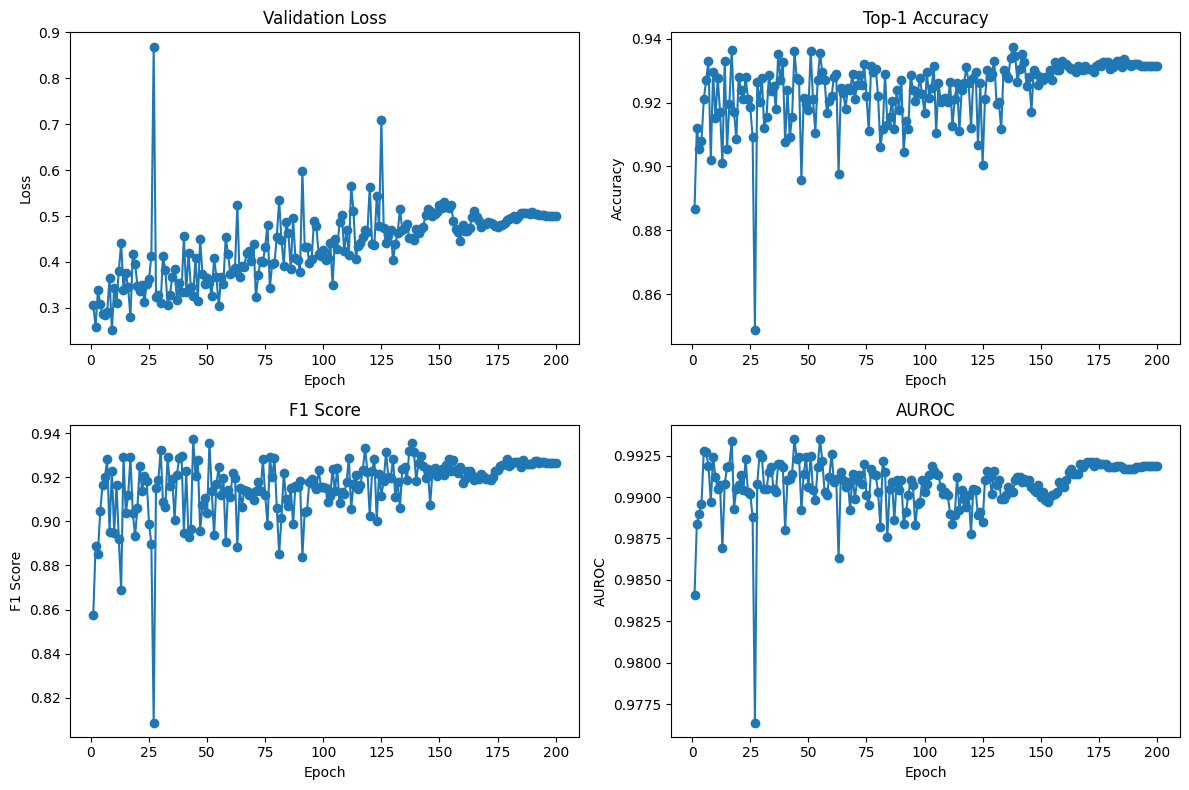

In [2]:
import re
import matplotlib.pyplot as plt

# 로그 파일 경로
log_file_path = 'train_convnextv2.txt'

# 로그 파일에서 문자열 읽기
with open(log_file_path, 'r', encoding='utf-8') as f:
    log = f.read()


# 정규식 패턴 정의
epoch_pattern = r"\[.*?\] Epoch \[(\d+)/\d+\] Validation:"
metrics_pattern = r"Val Loss: ([0-9.]+), Top-1 Acc: ([0-9.]+), Top-3 Acc: ([0-9.]+)\s+🔸 F1: ([0-9.]+), Recall: ([0-9.]+), Precision: ([0-9.]+), AUROC: ([0-9.]+)"

# 추출용 리스트
epochs, losses, accs, f1s, aurocs = [], [], [], [], []

# 로그에서 모든 epoch과 지표 추출
epoch_matches = re.findall(epoch_pattern, log)
metrics_matches = re.findall(metrics_pattern, log)

for i, (val_loss, top1_acc, top3_acc, f1, recall, precision, auroc) in enumerate(metrics_matches):
    epoch = int(epoch_matches[i])
    epochs.append(epoch)
    losses.append(float(val_loss))
    accs.append(float(top1_acc))
    f1s.append(float(f1))
    aurocs.append(float(auroc))

# 최댓값 기록
best_loss_epoch = epochs[losses.index(min(losses))]
best_acc_epoch = epochs[accs.index(max(accs))]
best_f1_epoch = epochs[f1s.index(max(f1s))]
best_auroc_epoch = epochs[aurocs.index(max(aurocs))]

# 출력
print(f"📉 Best Val Loss: {min(losses):.4f} at Epoch {best_loss_epoch}")
print(f"✅ Best Top-1 Accuracy: {max(accs):.4f} at Epoch {best_acc_epoch}")
print(f"📊 Best F1 Score: {max(f1s):.4f} at Epoch {best_f1_epoch}")
print(f"📈 Best AUROC: {max(aurocs):.4f} at Epoch {best_auroc_epoch}")

# 시각화
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs, losses, marker='o')
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 2, 2)
plt.plot(epochs, accs, marker='o')
plt.title("Top-1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(2, 2, 3)
plt.plot(epochs, f1s, marker='o')
plt.title("F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")

plt.subplot(2, 2, 4)
plt.plot(epochs, aurocs, marker='o')
plt.title("AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")

plt.tight_layout()
plt.show()
